In [1]:
"""
Day 4: Data Analysis & ADX Indicator
Goal: Deep dive into BTC data and learn regime detection
"""

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime
from ta.trend import ADXIndicator

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ Imports successful!")
print("📊 Day 4: Data Analysis & ADX Indicator\n")

✅ Imports successful!
📊 Day 4: Data Analysis & ADX Indicator



In [2]:
# Download BTC data to present day
ticker = 'BTC-USD'
start_date = '2020-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')

print(f"Downloading {ticker} from {start_date} to {end_date}...")
df = yf.download(ticker, start=start_date, end=end_date, progress=False)

print(f"✅ Downloaded {len(df)} days of data")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}\n")

# Show first few rows
print("First 5 rows:")
df.head()

✅ Downloaded 2227 days of data
Date range: 2020-01-01 to 2026-02-04

First 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


In [4]:
# Calculate descriptive statistics
print("="*60)
print("BITCOIN DESCRIPTIVE STATISTICS")
print("="*60)

# Price statistics
close_prices = df['Close']

print(f"\nPRICE:")
print(f"  Starting Price:  ${close_prices.iloc[0].item():,.2f}")
print(f"  Ending Price:    ${close_prices.iloc[-1].item():,.2f}")
print(f"  Lowest Price:    ${close_prices.min().item():,.2f}")
print(f"  Highest Price:   ${close_prices.max().item():,.2f}")
print(f"  Average Price:   ${close_prices.mean().item():,.2f}")
print(f"  Median Price:    ${close_prices.median().item():,.2f}")

# Daily changes
df['Daily_Change_Pct'] = df['Close'].pct_change() * 100

print(f"\nDAILY CHANGES:")
print(f"  Average:         {df['Daily_Change_Pct'].mean():.4f}%")
print(f"  Median:          {df['Daily_Change_Pct'].median():.4f}%")
print(f"  Std Dev:         {df['Daily_Change_Pct'].std():.4f}%")
print(f"  Best Day:        {df['Daily_Change_Pct'].max():.2f}%")
print(f"  Worst Day:       {df['Daily_Change_Pct'].min():.2f}%")

# Up vs Down days
up_days = (df['Daily_Change_Pct'] > 0).sum()
down_days = (df['Daily_Change_Pct'] < 0).sum()
flat_days = (df['Daily_Change_Pct'] == 0).sum()

print(f"\nUP vs DOWN DAYS:")
print(f"  Up Days:         {up_days} ({up_days/len(df)*100:.2f}%)")
print(f"  Down Days:       {down_days} ({down_days/len(df)*100:.2f}%)")
print(f"  Flat Days:       {flat_days}")

print("="*60)

BITCOIN DESCRIPTIVE STATISTICS

PRICE:
  Starting Price:  $7,200.17
  Ending Price:    $73,019.70
  Lowest Price:    $4,970.79
  Highest Price:   $124,752.53
  Average Price:   $47,849.04
  Median Price:    $40,527.36

DAILY CHANGES:
  Average:         0.1555%
  Median:          0.0398%
  Std Dev:         3.1799%
  Best Day:        18.75%
  Worst Day:       -37.17%

UP vs DOWN DAYS:
  Up Days:         1133 (50.88%)
  Down Days:       1093 (49.08%)
  Flat Days:       0


In [6]:
# Calculate ADX using ta library
print("Calculating ADX indicator...")

# Flatten column names (yfinance sometimes creates multi-level columns)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

# Ensure we have 1D Series
high = df['High'].squeeze()
low = df['Low'].squeeze()
close = df['Close'].squeeze()

print(f"Data shapes: High={high.shape}, Low={low.shape}, Close={close.shape}")

# ADX requires High, Low, Close
adx_indicator = ADXIndicator(
    high=high,
    low=low,
    close=close,
    window=14  # Standard 14-day period
)

# Extract the ADX components
df['ADX'] = adx_indicator.adx()
df['+DI'] = adx_indicator.adx_pos()  # Positive Directional Indicator
df['-DI'] = adx_indicator.adx_neg()  # Negative Directional Indicator

# Drop initial NaN values (first 14 days don't have ADX)
df_clean = df.dropna()

print(f"✅ ADX calculated for {len(df_clean)} days")
print(f"   (Removed {len(df) - len(df_clean)} NaN rows)\n")

# Show ADX statistics
print("="*60)
print("ADX STATISTICS")
print("="*60)
print(f"Average ADX:     {df_clean['ADX'].mean():.2f}")
print(f"Median ADX:      {df_clean['ADX'].median():.2f}")
print(f"Min ADX:         {df_clean['ADX'].min():.2f}")
print(f"Max ADX:         {df_clean['ADX'].max():.2f}")

# Regime breakdown
choppy = (df_clean['ADX'] < 25).sum()
trending = (df_clean['ADX'] >= 25).sum()

print(f"\nREGIME BREAKDOWN:")
print(f"  Choppy (ADX < 25):    {choppy} days ({choppy/len(df_clean)*100:.2f}%)")
print(f"  Trending (ADX >= 25): {trending} days ({trending/len(df_clean)*100:.2f}%)")
print("="*60)

# Show recent values
print(f"\nLast 10 days ADX:")
df_clean[['Close', 'ADX', '+DI', '-DI']].tail(10)

Calculating ADX indicator...
Data shapes: High=(2227,), Low=(2227,), Close=(2227,)
✅ ADX calculated for 2226 days
   (Removed 1 NaN rows)

ADX STATISTICS
Average ADX:     28.88
Median ADX:      26.43
Min ADX:         0.00
Max ADX:         70.30

REGIME BREAKDOWN:
  Choppy (ADX < 25):    982 days (44.12%)
  Trending (ADX >= 25): 1244 days (55.88%)

Last 10 days ADX:


Price,Close,ADX,+DI,-DI
Date,,,,
2026-01-26,88267.140625,25.700061,17.246038,28.271191
2026-01-27,89102.570312,25.182125,18.169200,26.389888
2026-01-28,89184.570312,24.117843,20.330397,24.990354
2026-01-29,84561.585938,24.964924,16.972761,36.048053
2026-01-30,84128.656250,26.251839,15.352515,38.498696
2026-01-31,78621.117188,28.348077,12.358259,43.308538
2026-02-01,76974.445312,30.311319,11.322602,39.949699
2026-02-02,78688.765625,32.300896,10.134480,38.315756
2026-02-03,75633.546875,34.374730,8.817484,36.791641


In [8]:
# Create visualization of ADX and regimes
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# --- PANEL 1: BTC PRICE ---
ax1.plot(df_clean.index, df_clean['Close'], linewidth=1.5, color='black')
ax1.set_ylabel('BTC Price (USD)', fontsize=12)
ax1.set_title('Bitcoin Price & ADX Regime Analysis', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.set_yscale('log')  # Log scale shows trends better

# --- PANEL 2: ADX WITH REGIME ZONES ---
# Plot ADX line
ax2.plot(df_clean.index, df_clean['ADX'], linewidth=2, color='purple', label='ADX')

# Add regime threshold line
ax2.axhline(y=25, color='red', linestyle='--', linewidth=2, label='Trend Threshold (25)')

# Color-code regime zones
ax2.fill_between(df_clean.index, 0, 25, alpha=0.2, color='green', label='Choppy Zone (<25)')
ax2.fill_between(df_clean.index, 25, 100, alpha=0.2, color='red', label='Trending Zone (>25)')

ax2.set_ylabel('ADX Value', fontsize=12)
ax2.set_ylim(0, 80)
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

# --- PANEL 3: +DI vs -DI (DIRECTION) ---
ax3.plot(df_clean.index, df_clean['+DI'], linewidth=1.5, color='green', label='+DI (Bullish)')
ax3.plot(df_clean.index, df_clean['-DI'], linewidth=1.5, color='red', label='-DI (Bearish)')
ax3.fill_between(df_clean.index, df_clean['+DI'], df_clean['-DI'], 
                  where=(df_clean['+DI'] > df_clean['-DI']), alpha=0.3, color='green', label='Bullish Dominance')
ax3.fill_between(df_clean.index, df_clean['+DI'], df_clean['-DI'], 
                  where=(df_clean['+DI'] <= df_clean['-DI']), alpha=0.3, color='red', label='Bearish Dominance')

ax3.set_ylabel('Directional Indicators', fontsize=12)
ax3.set_xlabel('Date', fontsize=12)
ax3.legend(loc='upper left')
ax3.grid(alpha=0=0.3)

plt.tight_layout()
plt.savefig('adx_regime_analysis.png', dpi=300, bbox_inches='tight')
print("✅ ADX chart saved as 'adx_regime_analysis.png'")
plt.show()

print(f"\n🎯 Current Market State (as of {df_clean.index[-1].date()}):")
print(f"   ADX: {df_clean['ADX'].iloc[-1]:.2f} → {'TRENDING' if df_clean['ADX'].iloc[-1] >= 25 else 'CHOPPY'}")
print(f"   +DI: {df_clean['+DI'].iloc[-1]:.2f}")
print(f"   -DI: {df_clean['-DI'].iloc[-1]:.2f}")
if df_clean['+DI'].iloc[-1] > df_clean['-DI'].iloc[-1]:
    print(f"   Direction: BULLISH (+DI > -DI)")
else:
    print(f"   Direction: BEARISH (-DI > +DI)")

SyntaxError: invalid syntax (1614755228.py, line 38)

✅ ADX chart saved as 'adx_regime_analysis.png'


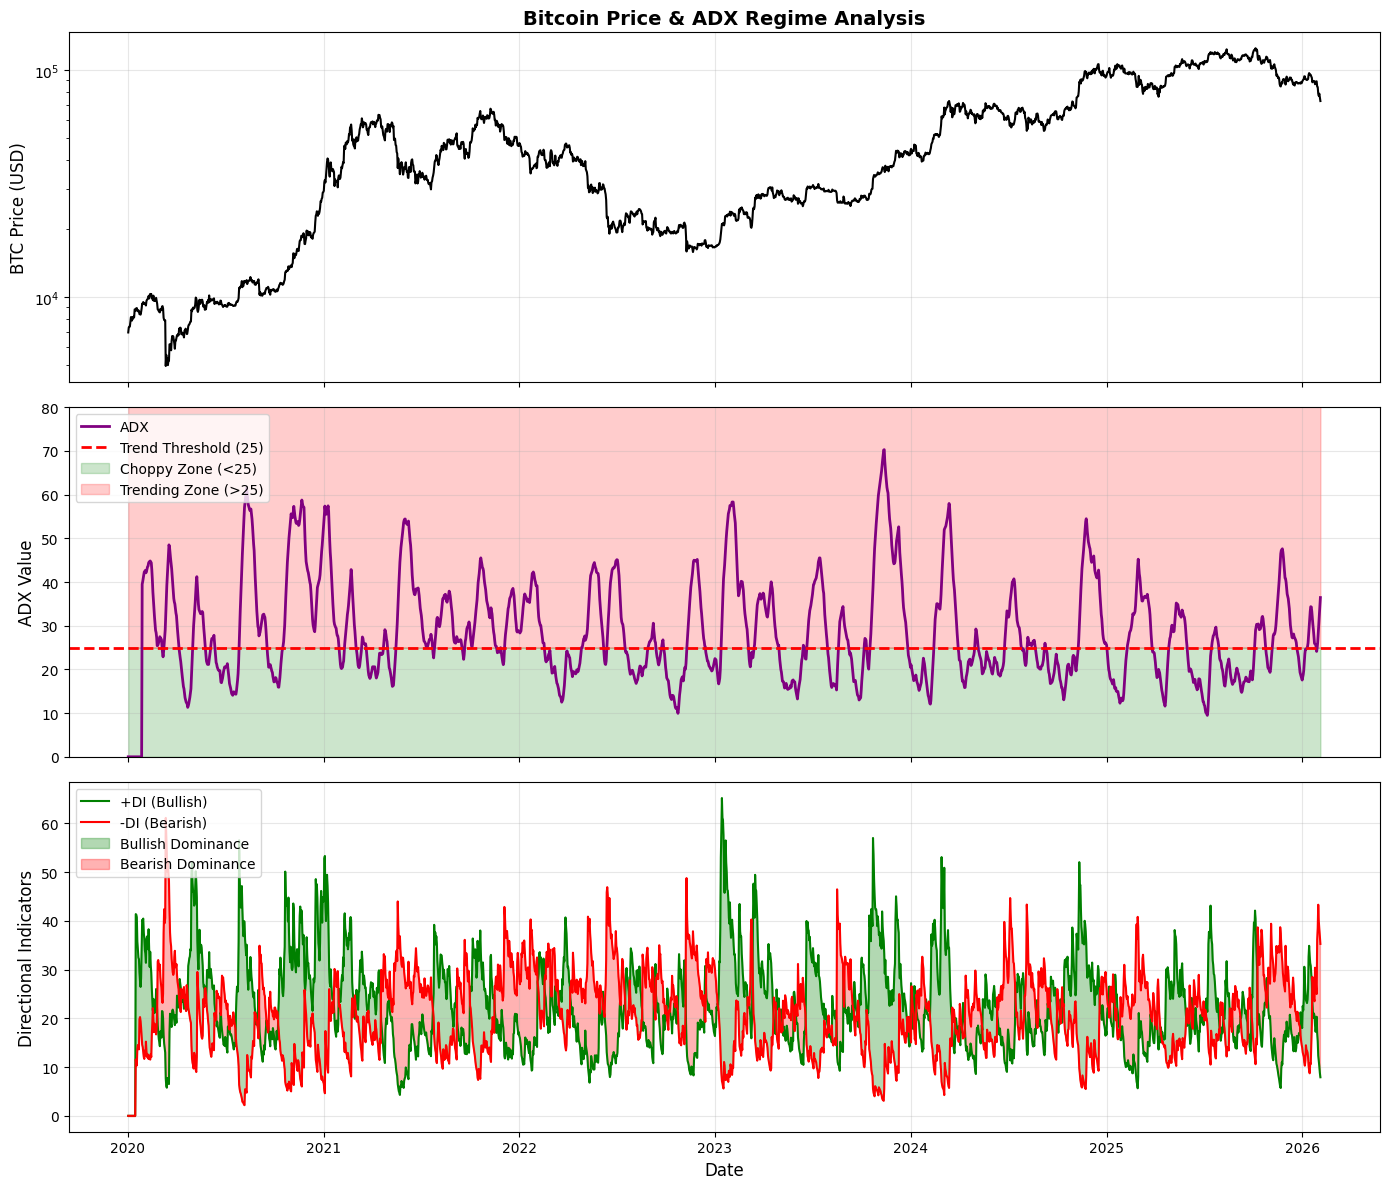


🎯 Current Market State (as of 2026-02-04):
   ADX: 36.44 → TRENDING
   +DI: 7.91
   -DI: 35.27
   Direction: BEARISH (-DI > +DI)


In [9]:
# Create visualization of ADX and regimes
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# --- PANEL 1: BTC PRICE ---
ax1.plot(df_clean.index, df_clean['Close'], linewidth=1.5, color='black')
ax1.set_ylabel('BTC Price (USD)', fontsize=12)
ax1.set_title('Bitcoin Price & ADX Regime Analysis', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.set_yscale('log')  # Log scale shows trends better

# --- PANEL 2: ADX WITH REGIME ZONES ---
# Plot ADX line
ax2.plot(df_clean.index, df_clean['ADX'], linewidth=2, color='purple', label='ADX')

# Add regime threshold line
ax2.axhline(y=25, color='red', linestyle='--', linewidth=2, label='Trend Threshold (25)')

# Color-code regime zones
ax2.fill_between(df_clean.index, 0, 25, alpha=0.2, color='green', label='Choppy Zone (<25)')
ax2.fill_between(df_clean.index, 25, 100, alpha=0.2, color='red', label='Trending Zone (>25)')

ax2.set_ylabel('ADX Value', fontsize=12)
ax2.set_ylim(0, 80)
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

# --- PANEL 3: +DI vs -DI (DIRECTION) ---
ax3.plot(df_clean.index, df_clean['+DI'], linewidth=1.5, color='green', label='+DI (Bullish)')
ax3.plot(df_clean.index, df_clean['-DI'], linewidth=1.5, color='red', label='-DI (Bearish)')
ax3.fill_between(df_clean.index, df_clean['+DI'], df_clean['-DI'], 
                  where=(df_clean['+DI'] > df_clean['-DI']), alpha=0.3, color='green', label='Bullish Dominance')
ax3.fill_between(df_clean.index, df_clean['+DI'], df_clean['-DI'], 
                  where=(df_clean['+DI'] <= df_clean['-DI']), alpha=0.3, color='red', label='Bearish Dominance')

ax3.set_ylabel('Directional Indicators', fontsize=12)
ax3.set_xlabel('Date', fontsize=12)
ax3.legend(loc='upper left')
ax3.grid(alpha=0.3)  # ← FIXED: Changed alpha=0=0.3 to alpha=0.3

plt.tight_layout()
plt.savefig('adx_regime_analysis.png', dpi=300, bbox_inches='tight')
print("✅ ADX chart saved as 'adx_regime_analysis.png'")
plt.show()

print(f"\n🎯 Current Market State (as of {df_clean.index[-1].date()}):")
print(f"   ADX: {df_clean['ADX'].iloc[-1]:.2f} → {'TRENDING' if df_clean['ADX'].iloc[-1] >= 25 else 'CHOPPY'}")
print(f"   +DI: {df_clean['+DI'].iloc[-1]:.2f}")
print(f"   -DI: {df_clean['-DI'].iloc[-1]:.2f}")
if df_clean['+DI'].iloc[-1] > df_clean['-DI'].iloc[-1]:
    print(f"   Direction: BULLISH (+DI > -DI)")
else:
    print(f"   Direction: BEARISH (-DI > +DI)")